In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import shap

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = data.target

print(X.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:",X_train.shape)
print("Testing data shape:",X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [10]:
model=RandomForestClassifier()

model.fit(X_train,y_train)

print("Model trained successfully")

Model trained successfully


In [5]:
predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:",accuracy)

Accuracy: 0.9649122807017544


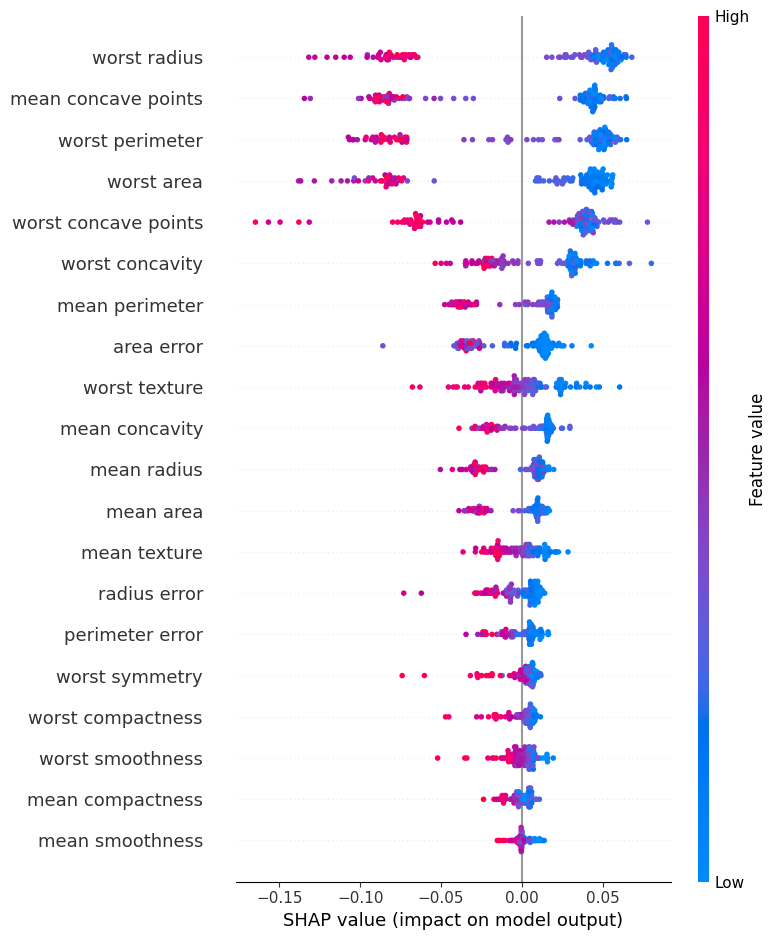

In [7]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

**Observations:**

1. Mean radius is one of the most important features affecting prediction.

2. Mean area strongly influences classification results.

3. Mean texture has moderate impact on prediction.

4. Features at the top contribute more than features at the bottom.

5. SHAP improves transparency by explaining why the model made decisions.

In [8]:
gender=np.random.choice(
    ['Male','Female'],
    len(X_test)
)

results=pd.DataFrame({
    'Gender':gender,
    'Prediction':predictions
})

print(
results.groupby(
'Gender'
).Prediction.mean()
)

Gender
Female    0.612245
Male      0.661538
Name: Prediction, dtype: float64


**Mitigation Recommendations :**
1. Use balanced datasets.
2. Remove biased attributes.
3. Test on diverse groups.
4. Monitor model predictions regularly.
5. Improve transparency.